In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [34]:
df = pd.read_csv(
    r"C:\Users\HP\OneDrive\Desktop\IIT Internship\Diwali Sales Data.csv",
    encoding="latin1"
)
df.head()


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [35]:
df.shape

(11251, 15)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [37]:
df.drop(['Status', 'unnamed1', 'User_ID', 'Cust_name'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_ID        11251 non-null  object 
 1   Gender            11251 non-null  object 
 2   Age Group         11251 non-null  object 
 3   Age               11251 non-null  int64  
 4   Marital_Status    11251 non-null  int64  
 5   State             11251 non-null  object 
 6   Zone              11251 non-null  object 
 7   Occupation        11251 non-null  object 
 8   Product_Category  11251 non-null  object 
 9   Orders            11251 non-null  int64  
 10  Amount            11239 non-null  float64
dtypes: float64(1), int64(3), object(7)
memory usage: 967.0+ KB


In [38]:
df.rename(columns={'Age Group': 'Age_Group'}, inplace=True)
df.columns

Index(['Product_ID', 'Gender', 'Age_Group', 'Age', 'Marital_Status', 'State',
       'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount'],
      dtype='object')

In [10]:
df.dropna(subset=['Amount'], inplace=True)
df.isnull().sum()

Product_ID          0
Gender              0
Age_Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(8)

In [40]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.reset_index(drop=True, inplace=True)

In [15]:
df.to_csv("diwali_cleaned.csv", index=False)

In [16]:
df.head()

,Product_ID,Gender,Age_Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [17]:
df.dtypes

Product_ID           object
Gender               object
Age_Group            object
Age                   int64
Marital_Status        int64
State                object
Zone                 object
Occupation           object
Product_Category     object
Orders                int64
Amount              float64
dtype: object

In [18]:
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
df['Age_Group'] = pd.Categorical(df['Age_Group'], categories=age_order, ordered=True)

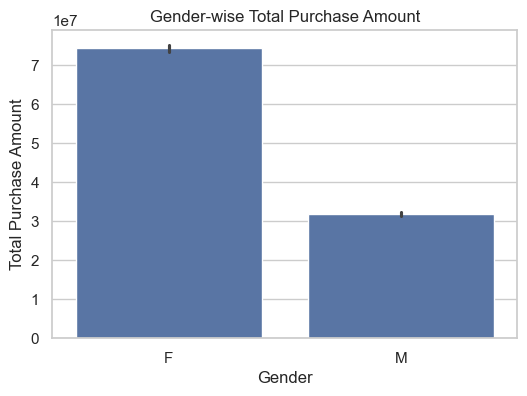

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Amount', data=df, estimator=np.sum)
plt.title('Gender-wise Total Purchase Amount')
plt.xlabel('Gender')
plt.ylabel('Total Purchase Amount')
plt.show()

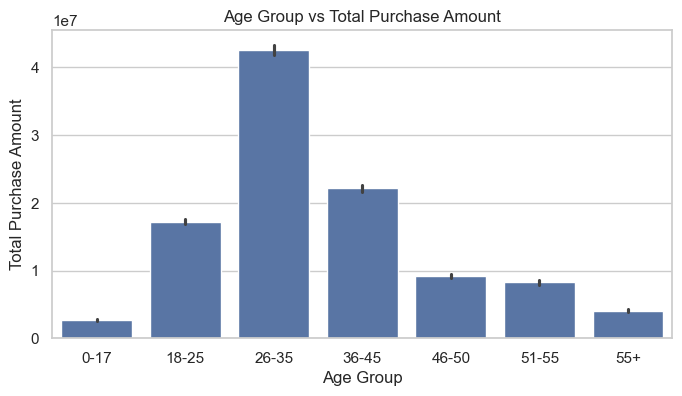

In [20]:
plt.figure(figsize=(8,4))
sns.barplot(x='Age_Group', y='Amount', data=df, estimator=np.sum)
plt.title('Age Group vs Total Purchase Amount')
plt.xlabel('Age Group')
plt.ylabel('Total Purchase Amount')
plt.show()

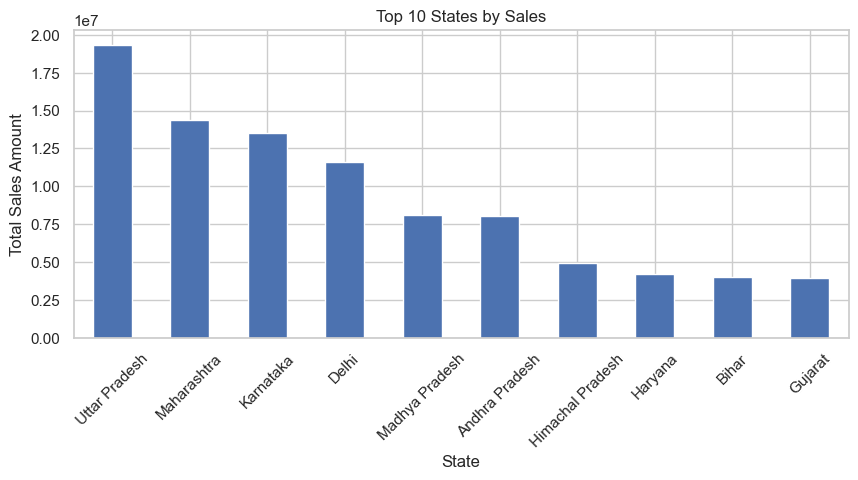

In [21]:
top_states = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,4))
top_states.plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.show()

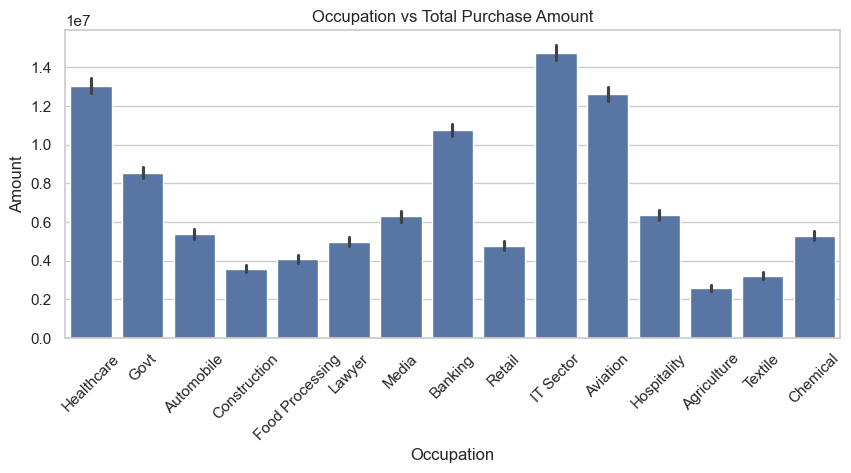

In [22]:
plt.figure(figsize=(10,4))
sns.barplot(x='Occupation', y='Amount', data=df, estimator=np.sum)
plt.title('Occupation vs Total Purchase Amount')
plt.xticks(rotation=45)
plt.show()

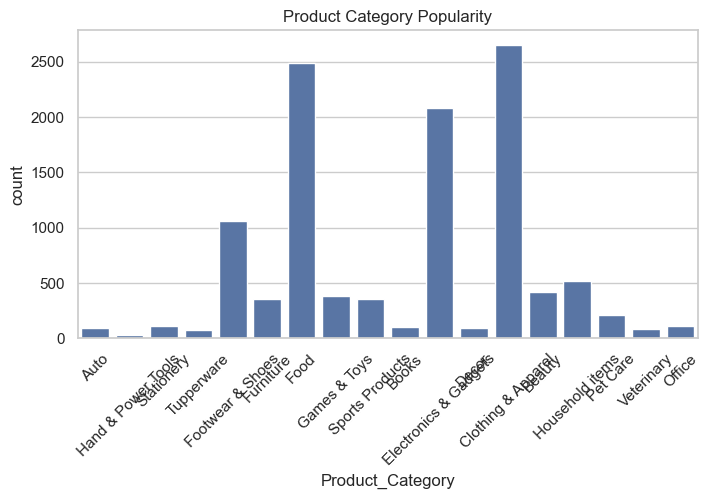

In [23]:
plt.figure(figsize=(8,4))
sns.countplot(x='Product_Category', data=df)
plt.title('Product Category Popularity')
plt.xticks(rotation=45)
plt.show()

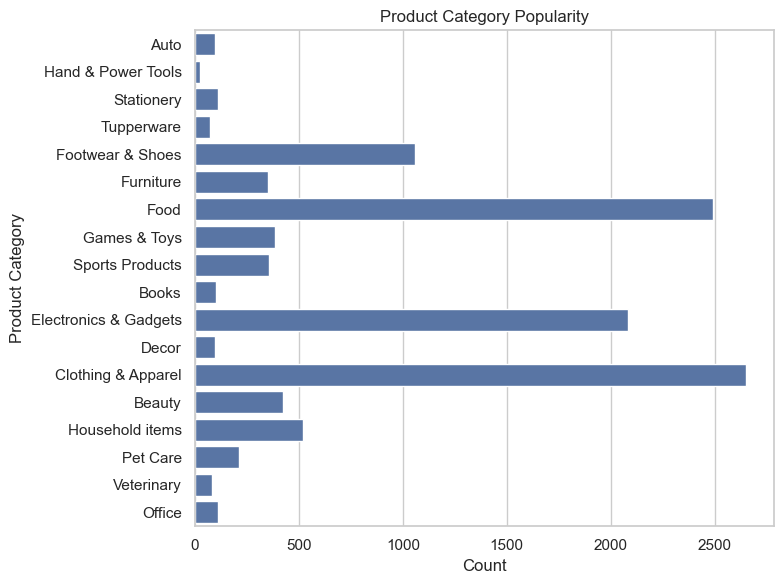

In [24]:
plt.figure(figsize=(8, 6))
sns.countplot(y='Product_Category', data=df)
plt.title('Product Category Popularity')
plt.xlabel('Count')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

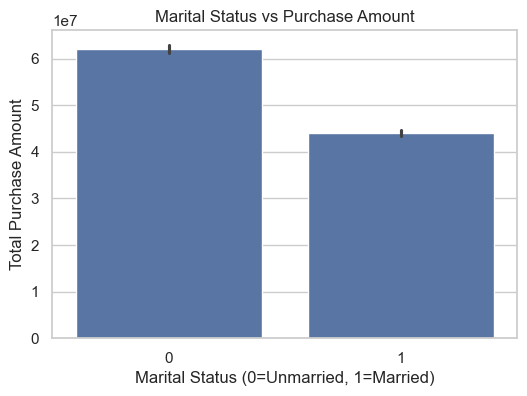

In [25]:
plt.figure(figsize=(6,4))
sns.barplot(x='Marital_Status', y='Amount', data=df, estimator=np.sum)
plt.title('Marital Status vs Purchase Amount')
plt.xlabel('Marital Status (0=Unmarried, 1=Married)')
plt.ylabel('Total Purchase Amount')
plt.show()

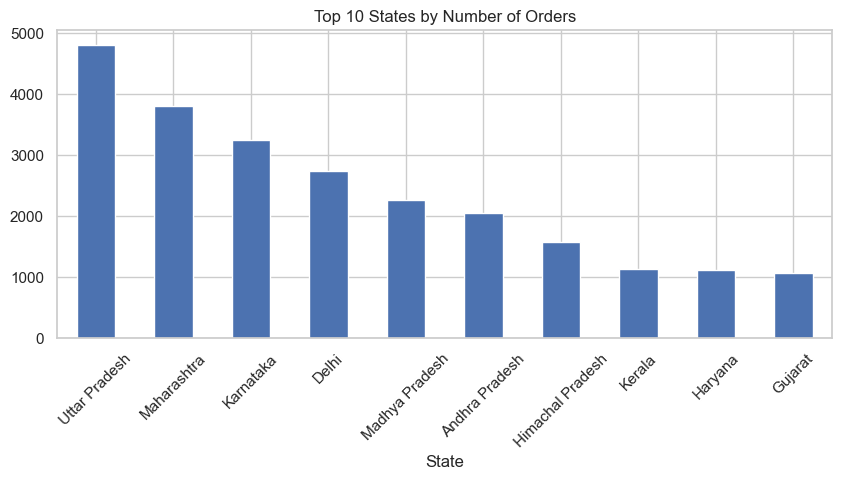

In [26]:
top_orders = df.groupby('State')['Orders'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,4))
top_orders.plot(kind='bar')
plt.title('Top 10 States by Number of Orders')
plt.xticks(rotation=45)
plt.show()

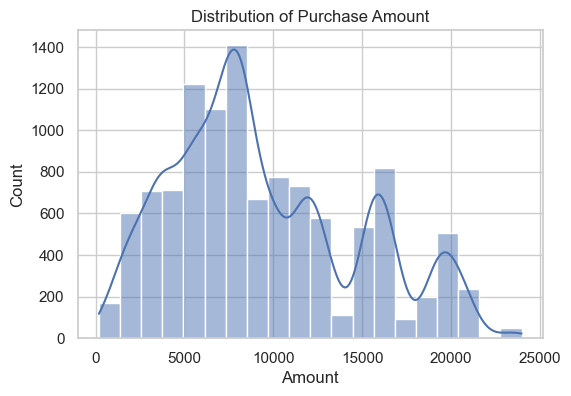

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=20, kde=True)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Amount')
plt.show()

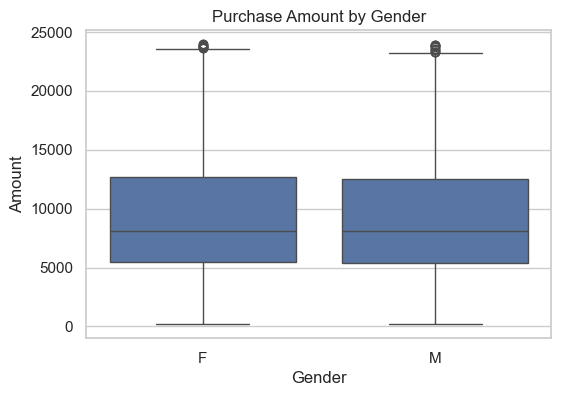

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Amount', data=df)
plt.title('Purchase Amount by Gender')
plt.show()

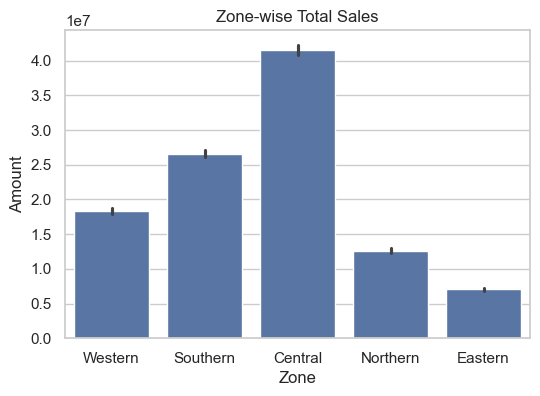

In [29]:
plt.figure(figsize=(6,4))
sns.barplot(x='Zone', y='Amount', data=df, estimator=np.sum)
plt.title('Zone-wise Total Sales')
plt.show()